In [8]:
import torch
import torch.nn.functional as F
import numpy as np
import timm
import matplotlib.pyplot as plt
from utils import do_2D_pca
from PIL import Image
from utils import load_image, resize_crop, to_norm_tensor, closest_crop
# DINOv2
#dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to("cuda")
#dinov2_vits14.eval()

from vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_MAP,
    FeatureType,
    MODEL_LIST,
)

vit_wrapper = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=False, device="cuda")

# creating images

In [151]:
white_img = np.ones((518,518), np.float16)
white_img_unsq = torch.tensor(white_img).unsqueeze(0).unsqueeze(0).repeat([1,3,1,1])
white_img_unsq.shape

torch.Size([1, 3, 518, 518])

In [20]:
black_img = np.zeros((1*518,1*518), np.float16)
black_img = torch.tensor(black_img).unsqueeze(0).unsqueeze(0).repeat([1,3,1,1])
black_img.shape

torch.Size([1, 3, 518, 518])

In [4]:
black_dog = load_image("black_dog.jpg", resize_crop((518,518), (518,518)))

In [5]:
micro_struct = load_image("default_image.jpg", resize_crop((2*518,2*518), (2*518,2*518)))

## Where to find the positional encoding

In [3]:
vit_wrapper

PretrainedViTWrapper(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
  

In [15]:
vit_wrapper.model.pos_embed.shape

torch.Size([1, 1369, 384])

Changing it

In [4]:
def get_sinusoid_encoding(num_tokens, token_len):
    """ Make Sinusoid Encoding Table

        Args:
            num_tokens (int): number of tokens
            token_len (int): length of a token
            
        Returns:
            (torch.FloatTensor) sinusoidal position encoding table
    """

    def get_position_angle_vec(i):
        return [i / np.power(10000, 2 * (j // 2) / token_len) for j in range(token_len)]

    sinusoid_table = np.array([get_position_angle_vec(i) for i in range(num_tokens)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2]) 

    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

In [48]:
new_pos_embedding = get_sinusoid_encoding(1369, 384).to(torch.float16) # needs to have the shape [1, 1369, 384]

In [49]:
new_pos_embedding

tensor([[[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
           0.0000e+00,  1.0000e+00],
         [ 8.4131e-01,  5.4053e-01,  8.1543e-01,  ...,  1.0000e+00,
           1.0490e-04,  1.0000e+00],
         [ 9.0918e-01, -4.1626e-01,  9.4434e-01,  ...,  1.0000e+00,
           2.0981e-04,  1.0000e+00],
         ...,
         [ 5.5859e-01, -8.2959e-01,  9.8535e-01,  ...,  9.8877e-01,
           1.4282e-01,  9.8975e-01],
         [-3.9600e-01, -9.1846e-01,  7.0947e-01,  ...,  9.8877e-01,
           1.4294e-01,  9.8975e-01],
         [-9.8682e-01, -1.6284e-01, -1.6382e-01,  ...,  9.8877e-01,
           1.4307e-01,  9.8975e-01]]], dtype=torch.float16)

In [53]:
zero_pos_embedding = torch.zeros((1, 1369, 384)).to(torch.float16)

to add a different embedding one needs to delete the original pos_embed beforehand

In [54]:
del vit_wrapper.model.pos_embed
#vit_wrapper.model.pos_embed = new_pos_embedding.to("cuda")
vit_wrapper.model.pos_embed = zero_pos_embedding.to("cuda")

In [5]:
vit_wrapper.eval()

PretrainedViTWrapper(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
  

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8779297..2.640625].


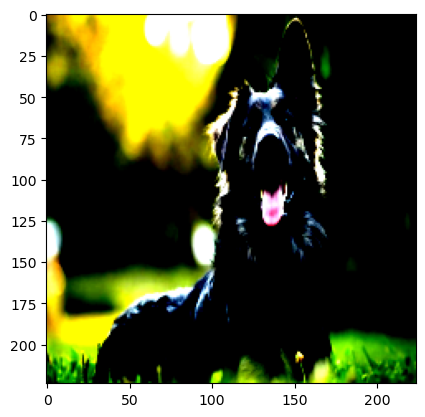

In [8]:
plt.imshow(black_dog[0].cpu().squeeze().transpose(0,2).transpose(0,1).float())

In [9]:
#res = vit_wrapper.forward_features(white_img_unsq.to("cuda"), make_2D=True)
res = vit_wrapper.forward_features(black_dog[0].to("cuda"), make_2D=True)

In [10]:
res.shape

torch.Size([1, 384, 16, 16])

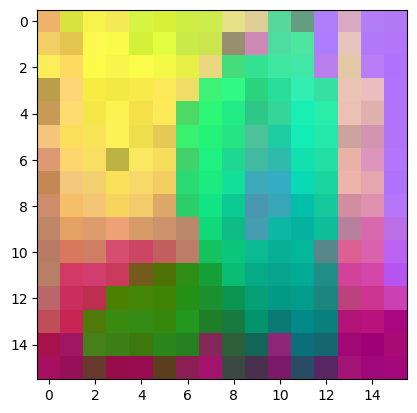

In [11]:
reduced_feats = do_2D_pca(res[0,::], n_components=3, post_norm="minmax")
plt.imshow(reduced_feats)

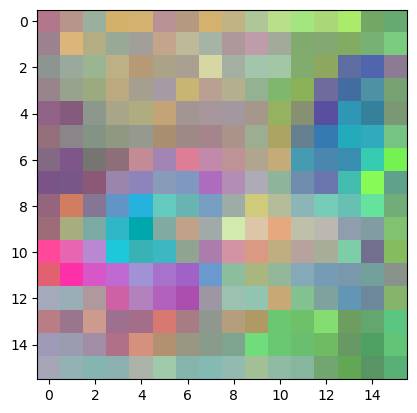

In [12]:
plt_img = np.transpose(res.detach().cpu().numpy().squeeze()[[1,4,10],:,:], (2,1,0)).astype(np.float32)

scaled_plt_img = ((plt_img - plt_img.min())/(plt_img.max()-plt_img.min()))
plt.imshow(scaled_plt_img)

In [13]:
#plt.hist(res.flatten().detach().cpu().numpy(), bins=200)

Model testing

In [14]:
from model import PEModel

vit_wrapper = PEModel.load_from_checkpoint("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/England/DINOMO/testing_dinov2/models/test-epoch=19-val_loss=0.23.ckpt")

In [15]:
res = vit_wrapper(black_dog[0].float().to("cuda"))
#res = vit_wrapper(white_img_unsq.float().to("cuda"))

In [38]:
res.shape

torch.Size([1, 384, 16, 16])

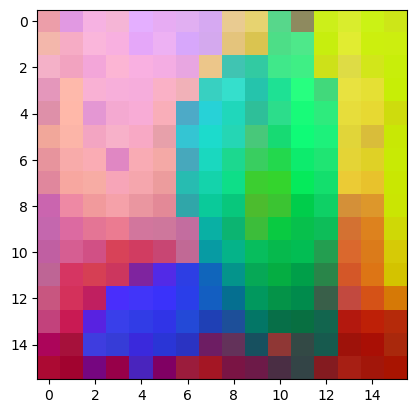

In [39]:
reduced_feats = do_2D_pca(res.squeeze().cpu(), n_components=3, post_norm="minmax")
plt.imshow(reduced_feats)

# testing how to homogenise vit output

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8779297..2.640625].


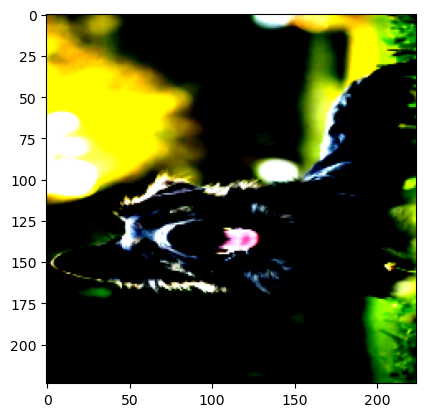

In [28]:
plt.imshow(black_dog[0].cpu().squeeze().transpose(0,2).float())

In [154]:
test_img = black_dog[0]#.flip(0,3)#.transpose(2,3)
#test_img = white_img_unsq.to("cuda")
test_img_rot = test_img.rot90(dims=(2,3))

def mean_image(image):
    def do_every_flip(test_img, rotation=False):
        res_orig = vit_wrapper.forward_features(test_img, make_2D=True)
        unflipped_rot = res_orig.squeeze() if not rotation else res_orig.rot90(3, (2, 3)).squeeze()
        pca_res_orig = unflipped_rot# do_2D_pca(unflipped_rot, post_norm="minmax")

        #test_img_flip = black_dog[0].flip(0,3)#.transpose(2,3)
        test_img_flip = test_img.flip(0,3).to("cuda")
        res_flip = vit_wrapper.forward_features(test_img_flip, make_2D=True)
        unflipped_rot = res_flip.flip(0,3).squeeze() if not rotation else res_flip.flip(0,3).rot90(3,(2,3)).squeeze()
        pca_res_flip = unflipped_rot# do_2D_pca(unflipped_rot, post_norm="minmax")

        #test_img_flip2 = black_dog[0].flip(0,2)#.transpose(2,3)
        test_img_flip2 = test_img.flip(0,2).to("cuda")
        res_flip2 = vit_wrapper.forward_features(test_img_flip2, make_2D=True)
        unflipped_rot = res_flip2.flip(0,2).squeeze() if not rotation else res_flip2.flip(0,2).rot90(3,(2,3)).squeeze()
        pca_res_flip2 = unflipped_rot# do_2D_pca(unflipped_rot, post_norm="minmax")

        test_img_flip3 = test_img.flip(0,2).flip(0,3).to("cuda")
        res_flip3 = vit_wrapper.forward_features(test_img_flip3, make_2D=True)
        unflipped_rot = res_flip3.flip(0,3).flip(0,2).squeeze() if not rotation else res_flip3.flip(0,3).flip(0,2).rot90(3,(2,3)).squeeze()
        pca_res_flip3 = unflipped_rot# do_2D_pca(unflipped_rot, post_norm="minmax")

        return (pca_res_flip + pca_res_orig + pca_res_flip2 + pca_res_flip3) / 4

    mean_res = do_every_flip(image)
    mean_rot_res = do_every_flip(image.rot90(dims=(2,3)), rotation=True)
    final_mean = (mean_res + mean_rot_res) / 2
    return final_mean

In [240]:
dinov3_vits16 = torch.hub.load("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/dinov3/dinov3", 'dinov3_vits16', source='local', weights="https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiNHkydHhxbHB2cTdxOWR1YjJxZ2QycTI5IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTk2Nzk4MjJ9fX1dfQ__&Signature=V3m6v-7UXSXLF%7EqDazuGFqOSkMl2%7EmYCrCybYqKMFUOP8t9mwFDFI-xmsYtDD7mSihjIheoK10z36xl797S3AI0889kyXlGC4IgV4xt2ZxjMqasY2wKOWwxTAL3NUYVVavLNxCvoo4lfIxnGSOcNY0T7NmMIANhtBPON-QO64cKkVJe2qz-ym8zaOyx9h095cDCtE4jhpRK6dwdjj6p9rqOHXc01lsJcO79t-HCsXAldTzWprDW32BIfqa3NZaKrCXrgsZ7X21-gJyE99dM-sH9tb3ty6EtNEAYM-9noud0Q52LZ-qB5shzI7LgI3RarUn0b275EA3hJKVLW1Pqv1Q__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=1116066683970834")

In [160]:
#test_img = white_img_unsq.to("cuda") #micro_struct[0]
test_img = load_image("images/default_image.jpg", resize_crop((2*518,2*518), (2*518, 2*518)))[0]
#test_img  = white_img_unsq.to("cuda")
#vit_wrapper.to("cuda").forward_features(test_img, make_2D=True) -
res_orig =  vit_wrapper.to("cuda").forward_features(image.to("cuda"), make_2D=True)

In [154]:
res_orig = res_orig.cpu()

In [27]:
import tifffile

In [28]:
tifffile.imwrite("zero_pos_embed_zero_img_feats.tiff", res_orig.detach().cpu().numpy())

In [187]:
feats = res_orig.detach().squeeze().cpu().numpy()
# feats[359, :, :] = 0
# feats[117, :, :] = 0
# feats[47, :, :] = 0
# feats[113, :, :] = 0
#feats[177, :, :] = 0

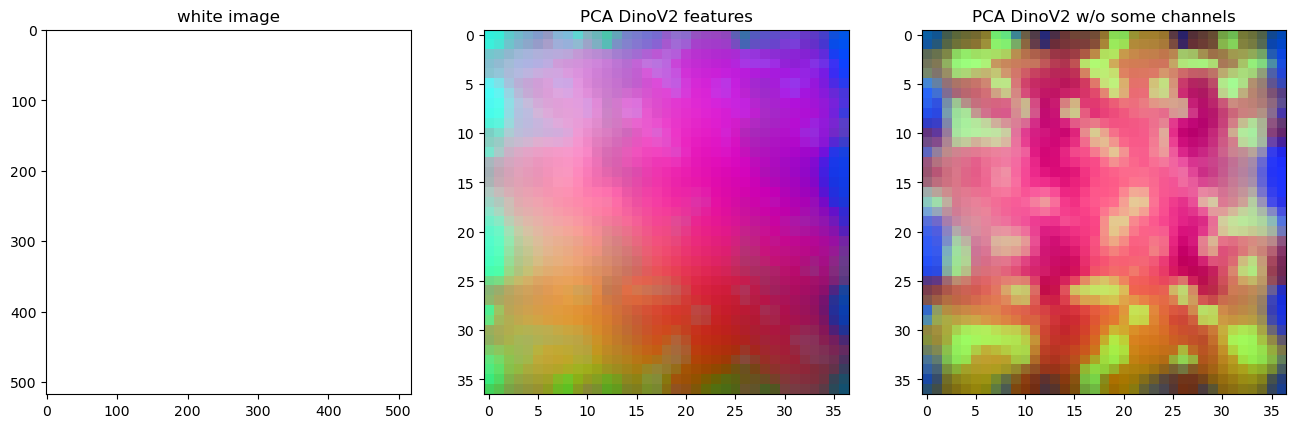

In [188]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(image.detach().cpu().squeeze().transpose(0,2).transpose(0,1).float())
ax[0].set_title("white image")
ax[1].imshow(do_2D_pca(feats, post_norm="minmax"))
ax[1].set_title("PCA DinoV2 features")
feats[359, :, :] = 0
feats[117, :, :] = 0
feats[47, :, :] = 0
feats[113, :, :] = 0
ax[2].set_title("PCA DinoV2 w/o some channels")
ax[2].imshow(do_2D_pca(feats, post_norm="minmax"))

In [26]:
tifffile.imwrite("8_518_default_feats.tiff", feats)

Text(0.5, 1.0, 'meaned by flipping and rotation')

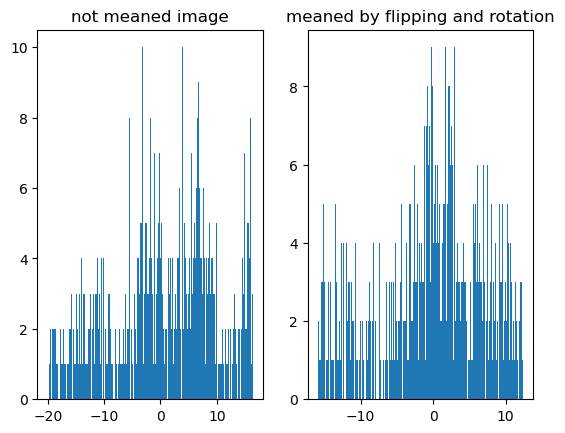

In [136]:
fig, ax = plt.subplots(1, 2)
ax[0].hist(do_2D_pca(vit_wrapper.forward_features(test_img, make_2D=True).squeeze()).flatten(), bins=300)
ax[0].set_title("not meaned image")
ax[1].hist(do_2D_pca(mean_image(test_img)).flatten(), bins=300)
ax[1].set_title("meaned by flipping and rotation")

In [104]:
test_img.shape

torch.Size([1, 3, 518, 518])

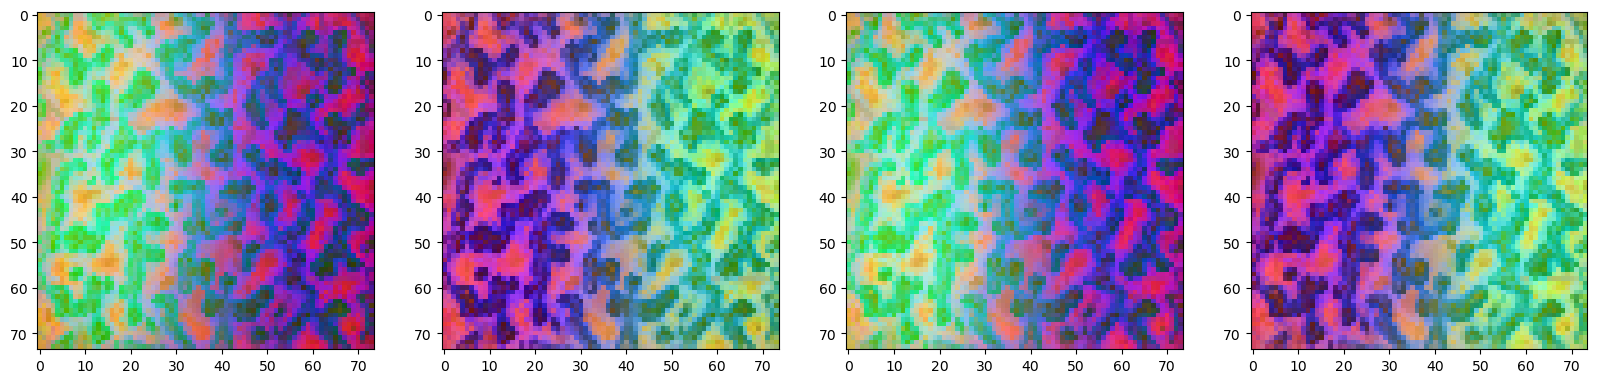

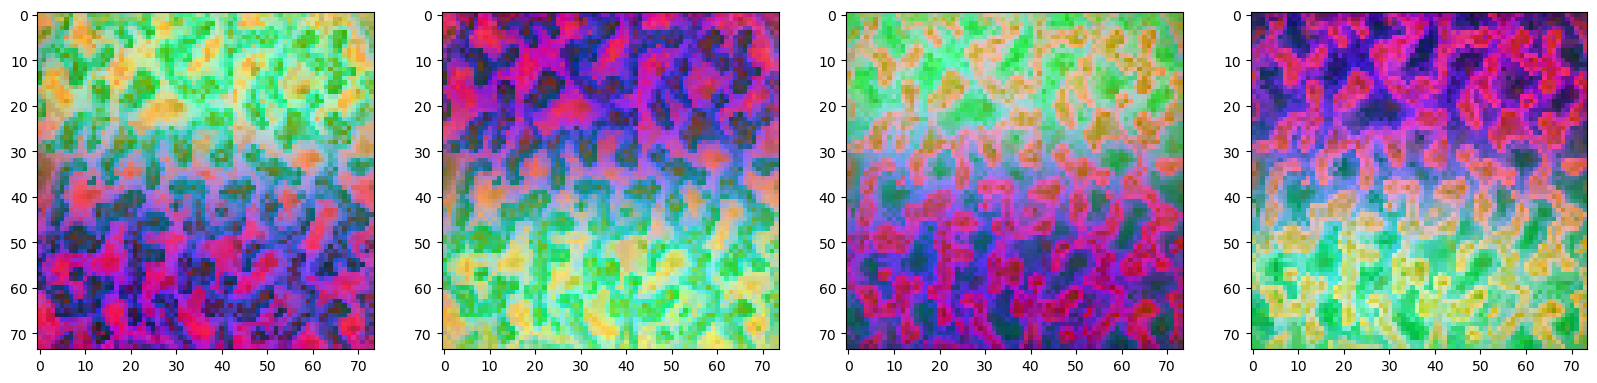

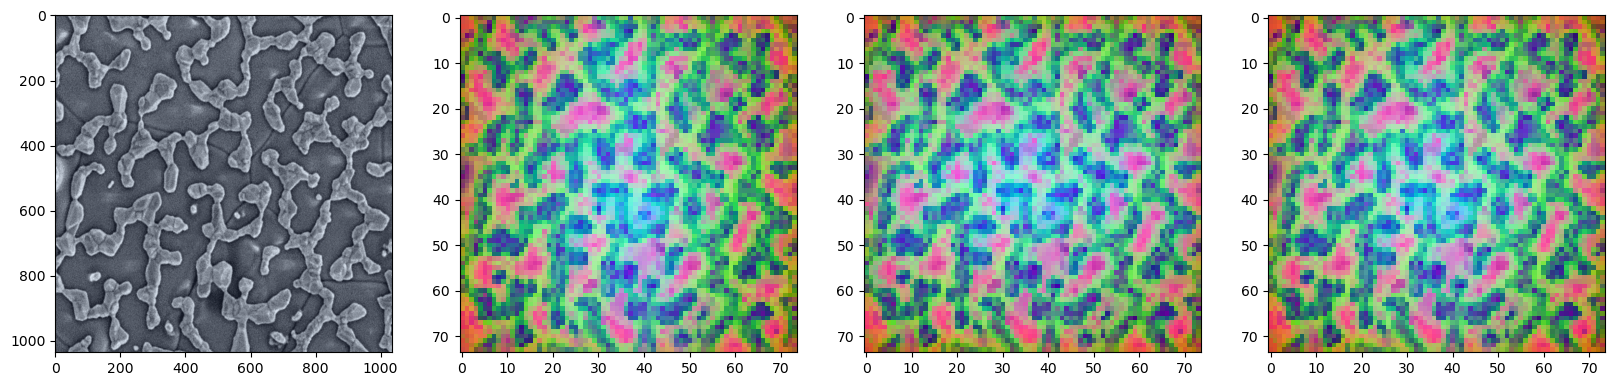

In [193]:
image = white_img_unsq.to("cuda")
image = load_image("images/default_image.jpg", resize_crop((2*518, 2*518), (2*518, 2*518)))[0]



def do_every_flip(test_img, rotation=False):
    fig, ax_ = plt.subplots(1, 4, figsize=(20,5))
    res_orig = vit_wrapper.forward_features(test_img, make_2D=True)
    unflipped_rot = res_orig.squeeze() if not rotation else res_orig.rot90(3, (2, 3)).squeeze()
    pca_res_orig = unflipped_rot# do_2D_pca(unflipped_rot, post_norm="minmax")
    ax_[0].imshow(do_2D_pca(unflipped_rot, post_norm="minmax"))
    #test_img_flip = black_dog[0].flip(0,3)#.transpose(2,3)
    test_img_flip = test_img.flip(0,3).to("cuda")
    res_flip = vit_wrapper.forward_features(test_img_flip, make_2D=True)
    unflipped_rot = res_flip.flip(0,3).squeeze() if not rotation else res_flip.flip(0,3).rot90(3,(2,3)).squeeze()
    pca_res_flip = unflipped_rot# do_2D_pca(unflipped_rot, post_norm="minmax")
    ax_[1].imshow(do_2D_pca(unflipped_rot, post_norm="minmax"))
    #test_img_flip2 = black_dog[0].flip(0,2)#.transpose(2,3)
    test_img_flip2 = test_img.flip(0,2).to("cuda")
    res_flip2 = vit_wrapper.forward_features(test_img_flip2, make_2D=True)
    unflipped_rot = res_flip2.flip(0,2).squeeze() if not rotation else res_flip2.flip(0,2).rot90(3,(2,3)).squeeze()
    pca_res_flip2 = unflipped_rot# do_2D_pca(unflipped_rot, post_norm="minmax")
    ax_[2].imshow(do_2D_pca(unflipped_rot, post_norm="minmax"))
    test_img_flip3 = test_img.flip(0,2).flip(0,3).to("cuda")
    res_flip3 = vit_wrapper.forward_features(test_img_flip3, make_2D=True)
    unflipped_rot = res_flip3.flip(0,3).flip(0,2).squeeze() if not rotation else res_flip3.flip(0,3).flip(0,2).rot90(3,(2,3)).squeeze()
    pca_res_flip3 = unflipped_rot# do_2D_pca(unflipped_rot, post_norm="minmax")
    ax_[3].imshow(do_2D_pca(unflipped_rot, post_norm="minmax"))
    return (pca_res_flip + pca_res_orig + pca_res_flip2 + pca_res_flip3) / 4

mean_res = do_every_flip(image)
mean_rot_res = do_every_flip(image.rot90(dims=(2,3)), rotation=True)
final_mean = (mean_res + mean_rot_res) / 2



fig, axes = plt.subplots(1,4, figsize=(20,5))

im_np = image.detach().cpu().squeeze().transpose(0,2).transpose(0,1).float()
im_np = (im_np - im_np.min())/(im_np.max()-im_np.min())

for ax, img in zip(axes.ravel(), [im_np,#test_img_rot.detach().cpu().squeeze().transpose(0,2).transpose(0,1).float(), 
                                  do_2D_pca(mean_res, post_norm="minmax"), do_2D_pca(mean_rot_res, post_norm="minmax"),
                                  do_2D_pca(final_mean, post_norm="minmax")]):
    ax.imshow(img)
# vertical flipping doesnt do anything??

In [109]:
res_orig = vit_wrapper.forward_features(test_img, make_2D=True)
unflipped_rot = res_orig.squeeze()
pca_res_orig = do_2D_pca(unflipped_rot, post_norm="minmax")

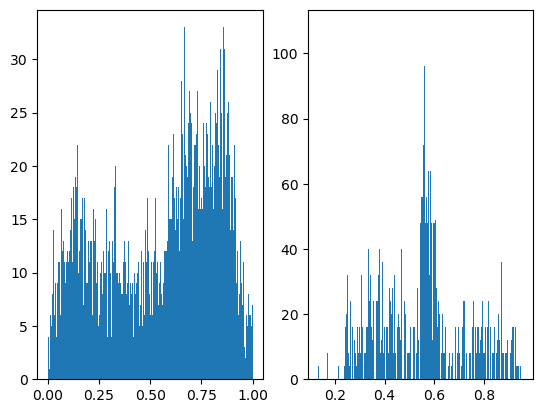

In [113]:
fig, axes = plt.subplots(1, 2)

for ax, data in zip(axes.ravel(), [pca_res_orig.flatten(), final_mean.flatten()]):
    ax.hist(data, bins=300)

# testing trained vit

In [17]:
trained_model = PEModel.load_from_checkpoint("models/test-epoch=15-val_loss=0.45.ckpt")

In [23]:
res  = trained_model(black_dog[0].to("cuda").float()).cpu()

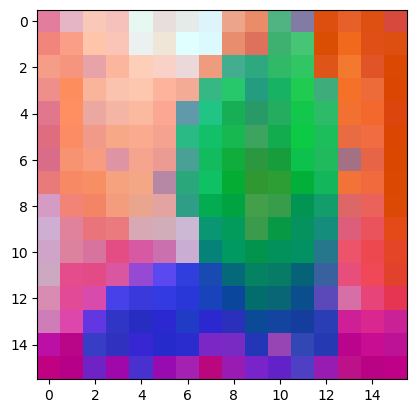

In [25]:
res_pca = do_2D_pca(res.squeeze(), post_norm="minmax")
plt.imshow(res_pca)

# adding relative position encoding

In [104]:
def no_pos_forward_features(self, x):
    """
    Take the typical timm VisionTransformer.forward_features skeleton
    and remove the x = x + self.pos_embed step.
    This function intentionally keeps cls_token behavior; remove cls handling
    if you want no cls token either.
    """
    B = x.shape[0]
    print(x.shape)
    # patch embedding -> (B, n_patches, embed_dim)
    x = self.patch_embed(x)

    print(x.shape) # b, h, w, c

    if x.ndim == 4:
        x = x.flatten(2).transpose(1, 2)

    # cls token handling (typical timm ViT)
    if hasattr(self, 'reg_tokens') and self.reg_tokens is not None:
        reg_tokens = self.reg_tokens.expand(B, -1, -1)
        x = torch.cat((reg_tokens, x), dim=1)

    # (Optionally keep CLS token)
    if hasattr(self, "cls_token") and self.cls_token is not None:
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

    # ---- skip positional embedding addition ----
    # do not do: x = x + self.pos_embed
    x = self.pos_drop(x)
    # transformer blocks
    for blk in self.blocks:
        x = blk(x)
    x = self.norm(x).transpose(1, 2)
    print(x.shape)
    # return same thing the original forward_features would return
    return x

def _pos_embed_no_pos(self, x):
    """
    Replacement for _pos_embed that:
    - Flattens (B, H, W, C) -> (B, N, C)
    - Prepends reg and cls tokens if present
    - SKIPS adding absolute positional embeddings
    """
    B = x.shape[0]

    # flatten spatial dims
    if x.ndim == 4:  # (B, H, W, C)
        x = x.reshape(B, -1, x.shape[-1])  # -> (B, N, C)

    # add reg tokens if model has them
    if hasattr(self, "reg_tokens") and self.reg_tokens is not None:
        reg_tokens = self.reg_tokens.expand(B, -1, -1)
        x = torch.cat((reg_tokens, x), dim=1)

    # add cls token if model has one
    if hasattr(self, "cls_token") and self.cls_token is not None:
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

    # ---- do NOT add pos_embed ----
    return x

In [140]:
from copy import deepcopy
test_model = deepcopy(vit_wrapper)
import types
#test_model.model.forward_features = types.MethodType(no_pos_forward_features, test_model.model)
#test_model._pos_embed = types.MethodType(_pos_embed_no_pos, test_model)


torch.Size([1, 384, 80, 80])


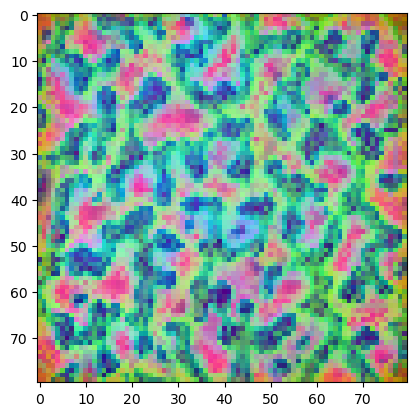

In [15]:
#test_img = white_img_unsq.to("cuda") #micro_struct[0]
test_img = load_image("images/default_image.jpg", resize_crop((5*224,5*224), (5*224, 5*224)))[0]
#test_img  = white_img_unsq.to("cuda")
#vit_wrapper.to("cuda").forward_features(test_img, make_2D=True) -
res_orig =  vit_wrapper.to("cuda").forward_features(test_img.float().to("cuda"), make_2D=True)
print(res_orig.shape)
feats = res_orig.detach().squeeze().cpu().numpy()
feats[359, :, :] = 0
feats[117, :, :] = 0
feats[47, :, :] = 0
feats[113, :, :] = 0
#feats[177, :, :] = 0
plt.imshow(do_2D_pca(feats, post_norm="minmax"))

In [16]:
from translation import translate

In [17]:
res  = translate(vit_wrapper, test_img, factor=16)

16it [00:01, 12.30it/s]


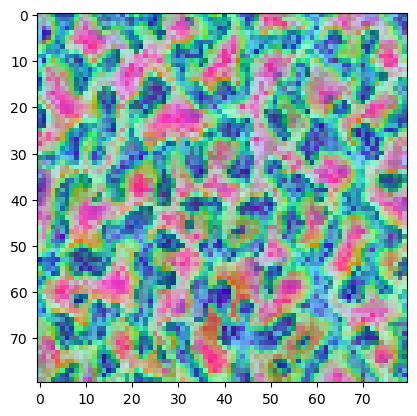

In [18]:
plt.imshow(do_2D_pca(res.squeeze(), post_norm="minmax"))